<a href="https://colab.research.google.com/github/manyanaidu28/Week4-Customer-Churn-Supervised-Learning/blob/main/Week4_Customer_Churn_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Inspect the dataset

print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill any missing values created during conversion
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Select numerical features for prediction
features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nFeature Shape:", X.shape)
print("\nMissing Values After Preprocessing:")
print(X.isnull().sum())

Selected Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Feature Shape: (7043, 4)

Missing Values After Preprocessing:
SeniorCitizen     0
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [ ]:
# Define target variable
y = df['Churn']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

print("\nChurn distribution:")
print(y.value_counts())

Training Features: (5634, 4)
Testing Features: (1409, 4)
Training Target: (5634,)
Testing Target: (1409,)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training shape: (5634, 4)
Scaled testing shape: (1409, 4)


In [ ]:
# Logistic Regression Model

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Evaluate Logistic Regression

accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Accuracy: 78.42 %

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.90      0.86      1035
         Yes       0.63      0.45      0.53       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409


Confusion Matrix:
[[935 100]
 [204 170]]


In [ ]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 76.37 %

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.88      0.84      1035
         Yes       0.57      0.45      0.50       374

    accuracy                           0.76      1409
   macro avg       0.69      0.66      0.67      1409
weighted avg       0.75      0.76      0.75      1409


Confusion Matrix:
[[907 128]
 [205 169]]


Feature Importance:
          Feature  Importance
2  MonthlyCharges    0.387206
3    TotalCharges    0.356689
1          tenure    0.228154
0   SeniorCitizen    0.027951


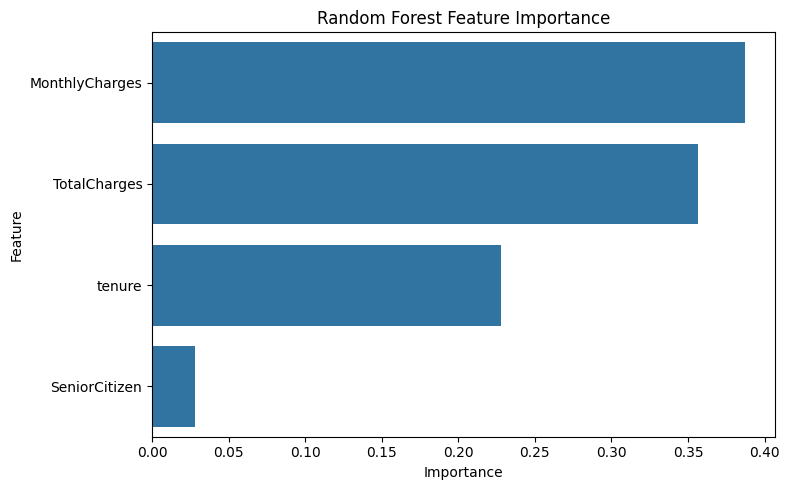

In [ ]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Model Performance Comparison:
                 Model  Accuracy
0  Logistic Regression  0.784244
1        Random Forest  0.763662


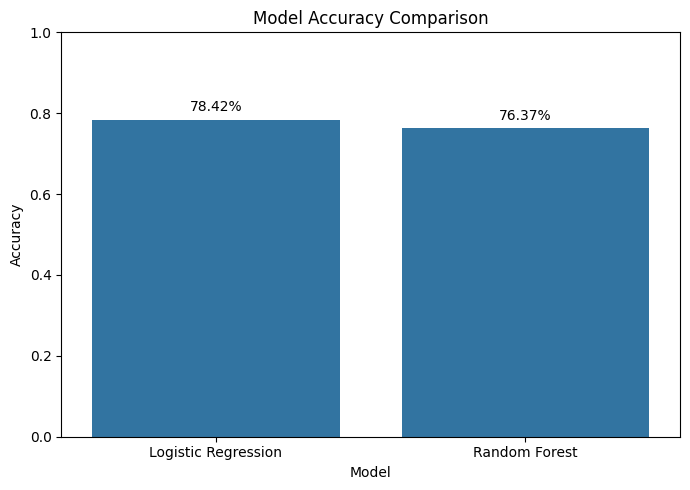

In [ ]:
# Model Comparison

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

print("Model Performance Comparison:")
print(model_comparison)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(model_comparison["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2%}", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# 5-Fold Cross-Validation

lr_cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression CV Scores:")
print(lr_cv_scores)
print("Mean CV Accuracy:", round(lr_cv_scores.mean() * 100, 2), "%")

print("\nRandom Forest CV Scores:")
print(rf_cv_scores)
print("Mean CV Accuracy:", round(rf_cv_scores.mean() * 100, 2), "%")

Logistic Regression CV Scores:
[0.80745342 0.79503106 0.7905945  0.78438332 0.77797513]
Mean CV Accuracy: 79.11 %

Random Forest CV Scores:
[0.75332742 0.78438332 0.76308784 0.76397516 0.74689165]
Mean CV Accuracy: 76.23 %


In [ ]:
# Final Model Performance Summary

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "5-Fold CV Accuracy": [
        lr_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

results["Test Accuracy"] = (results["Test Accuracy"] * 100).round(2)
results["5-Fold CV Accuracy"] = (results["5-Fold CV Accuracy"] * 100).round(2)

print("Final Model Performance:")
display(results)

best_model = results.loc[
    results["5-Fold CV Accuracy"].idxmax(), "Model"
]

print("\nBest Performing Model:", best_model)

Final Model Performance:


,Model,Test Accuracy,5-Fold CV Accuracy
0,Logistic Regression,78.42,79.11
1,Random Forest,76.37,76.23



Best Performing Model: Logistic Regression


Logistic Regression AUC: 0.8189
Random Forest AUC: 0.7712


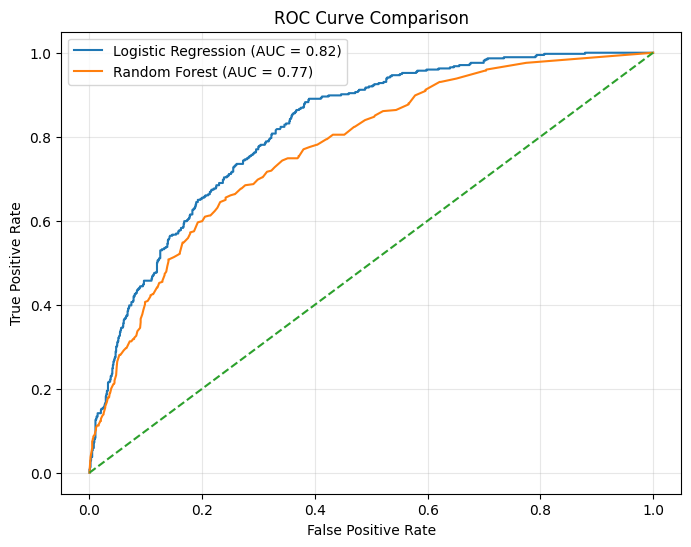

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_logistic,
    pos_label="Yes"
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf,
    pos_label="Yes"
)

# AUC scores
auc_lr = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_logistic
)

auc_rf = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_prob_rf
)

print("Logistic Regression AUC:", round(auc_lr, 4))
print("Random Forest AUC:", round(auc_rf, 4))

# ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.2f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Final Conclusion

print("FINAL CONCLUSION")
print("=" * 50)

print("Best Model: Logistic Regression")
print("Test Accuracy: 78.42%")
print("5-Fold Cross-Validation Accuracy: 79.11%")
print("ROC-AUC Score: {:.2f}".format(auc_lr))

print("\nKey Findings:")
print("1. Logistic Regression performed better than Random Forest.")
print("2. Logistic Regression achieved stronger accuracy and cross-validation performance.")
print("3. The ROC-AUC score indicates good ability to distinguish churned and non-churned customers.")
print("4. Monthly Charges and Total Charges were important predictive features.")
print("5. The model can help identify customers who are more likely to churn.")

FINAL CONCLUSION
Best Model: Logistic Regression
Test Accuracy: 78.42%
5-Fold Cross-Validation Accuracy: 79.11%
ROC-AUC Score: 0.82

Key Findings:
1. Logistic Regression performed better than Random Forest.
2. Logistic Regression achieved stronger accuracy and cross-validation performance.
3. The ROC-AUC score indicates good ability to distinguish churned and non-churned customers.
4. Monthly Charges and Total Charges were important predictive features.
5. The model can help identify customers who are more likely to churn.
